## Assignment 04 - Deadline: Mar 29, 2026, Sun 11pm

#### DSAI 541 Spring 2026

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [1]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML

# Set the display option to show all rows scrolling with a slider
pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

# Problem 1: ANN hyperparameter optimization with Breast Cancer Dataset (100 pts)

(You must use PyTorch in this problem. Answers implemented in TensorFlow will not be accepted.)

In this problem, you will use Breast Cancer Wisconsin dataset to train ANN classifier. The two classes in the dataset are malignant tumor (M) and benign tumor (B).

a) Load the Breast Cancer Wisconsin dataset. Split the dataset into training, validation and test sets. Then standardize the features using StandardScaler() while avoiding data leakage.

b) You will train an ANN binary classifier with two hidden layers. Choose three values for each of these three hyperparameters: Learning rate, batch size and number of neurons, assuming that both hidden layers have the same number of neurons. You will train $3\times3\times3=27$ models using early stopping.

c) Train the models and calculate accuracy, recall, precision and F1 score on the validation set for each model.

d) Which classification metric should you use assuming false negatives are more costly than false positives? What are the hyperparameters of the best model, which maximizes that metric?

e) Perform the final training of your best model and show training and validation curves. Show the confusion matrix with labels "actual" and "predicted" as we did in class.

f) Calculate the evaluation metric you choose in d) on the test set.

#### Part a)

In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import SGD
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch import nn
import itertools
import time
import copy

# Set random seeds for reproducibility
torch.manual_seed(3407)
np.random.seed(3407)
# Check if GPU is available and set device accordingly
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
data = pd.read_csv('Breast_Cancer_Wisconsin.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
X = data.drop(columns=['id', 'diagnosis', "Unnamed: 32"]) # Drop the 'id', 'diagnosis', and 'Unnamed: 32' columns
y = data['diagnosis'].map({'M': 1, 'B': 0}) # Map 'M' to 1 and 'B' to 0

In [6]:
# Set the sizes for training, validation, and test sets
train_size = int(0.8 * len(X))
val_size = int(0.1 * len(X))
test_size = len(X) - train_size - val_size

#split the data into training, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.90), stratify=y_temp, random_state=42)


# Scale the features using standart scaling
# We don't scale the target variable since it's binary (0 and 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert the data to PyTorch tensors
X_train_tensor = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.float32))
X_val_tensor = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
X_test_tensor = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32))

#### Part b)

In [7]:
# Hyperparameters we want to tune
learning_rates = [0.01, 0.001, 0.0001]
number_of_neurons = [40, 64, 128]
batch_sizes = [16, 32, 64] 

In [8]:
def create_dataloaders(batch_size):
    # Create DataLoaders for the training, validation, and test sets
    train_loader = DataLoader(X_train_tensor, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(X_val_tensor, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(X_test_tensor, batch_size=batch_size, shuffle=False)   
    return train_loader, val_loader

In [9]:
class BreastCancerANN(nn.Module):
    """
    Dynamic Breast Cancer Detection ANN for binary classification.
    """
    def __init__(self, hidden_size):
        # 30 -> h_s -> h_s -> output
        super(BreastCancerANN, self).__init__()

        self.input_layer = nn.Linear(30, hidden_size) # input to first hidden layer
        self.fc1 = nn.Linear(hidden_size, hidden_size) # first hidden layer to second hidden layer
        self.fc2 = nn.Linear(hidden_size, 1) # second hidden layer to output layer     

    def forward(self, x):
        x = self.input_layer(x)
        x = F.relu(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.sigmoid(x)
        return x

In [10]:
def train_model(model, train_loader, val_loader, optimizer, num_epochs=100):
    """ 
    """
    global criterion
    best_val_loss = float("inf")
    delta = 0.001
    best_model = copy.deepcopy(model.state_dict())
    last_improvement_epoch = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        run_epoch_train_loss = 0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1) # Reshape to (batch_size, 1)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            run_epoch_train_loss += loss.item()

        avg_train_loss = run_epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        run_epoch_val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).unsqueeze(1) # Reshape to (batch_size, 1)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                run_epoch_val_loss += loss.item()

        avg_val_loss = run_epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Early stopping based on validation loss
        if avg_val_loss < best_val_loss - delta:
            best_val_loss = avg_val_loss
            best_model = copy.deepcopy(model.state_dict())
            last_improvement_epoch = epoch
        elif epoch - last_improvement_epoch >= 10: # Stop if no improvement for 10 epochs
            print(f"Early stopping at epoch {epoch} with best validation loss: {best_val_loss:.4f}")
            break

    return train_losses, val_losses, best_val_loss, best_model, last_improvement_epoch

In [11]:
def hyp_opt(train_loader, val_loader, model,learning_rate, batch_size):
    optimizer = SGD(model.parameters(), lr=learning_rate, momentum=0.9, nesterov=True)
    train_losses, val_losses, best_val_loss, best_model, last_improvement_epoch = train_model(model, train_loader, val_loader, optimizer)
    return best_model, best_val_loss
    

#### Part c)

In [ ]:
best_val_loss_global = float("inf")
best_model_global = None
best_hyperparams = [0, 0, 0]
best_recall = -1
best_f1_score = -1

best_metrics = {
    "id": None,
    "Accuracy": None,
    "Precision": None,
    "Recall": None,
    "F1 Score": None,
    "Val_loss": None
}

criterion = nn.BCELoss() # Binary Cross-Entropy Loss for binary classification

start = time.perf_counter()

for lr, nr, bs in itertools.product(learning_rates, number_of_neurons, batch_sizes):
    current_metrics = {
        "id": f"lr:{lr} nr:{nr} bs:{bs}",
        "Accuracy": None,
        "Precision": None,
        "Recall": None,
        "F1 Score": None,
        "Val_loss": None
    }
    model = BreastCancerANN(hidden_size=nr).to(device)
    train_loader, val_loader = create_dataloaders(bs)

    print(f"Training with learning rate: {lr}, number of neurons: {nr}, batch size: {bs}")
    best_model, val_loss = hyp_opt(train_loader, val_loader, model, lr, bs)
    current_metrics["Val_loss"] = val_loss
    true_positive, true_negative, false_positive, false_negative = 0, 0, 0, 0

    model.load_state_dict(best_model) # Load the best model weights for evaluation

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1) # Reshape to (batch_size, 1)
            outputs = model(X_batch)
            # Calculate true positives, true negatives, false positives, and false negatives
            predicted = (outputs > 0.5).float() # Threshold at 0.5
            true_positive += ((predicted == 1) & (y_batch == 1)).sum().item()
            true_negative += ((predicted == 0) & (y_batch == 0)).sum().item()
            false_positive += ((predicted == 1) & (y_batch == 0)).sum().item()
            false_negative += ((predicted == 0) & (y_batch == 1)).sum().item()
    
    accuracy = (true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative) if (true_positive + true_negative + false_positive + false_negative) > 0 else 0
    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
    recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    current_metrics["Accuracy"] = accuracy
    current_metrics["Precision"] = precision
    current_metrics["Recall"] = recall
    current_metrics["F1 Score"] = f1_score
    print(f"Validation Metrics - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1_score:.4f}, Val Loss: {val_loss:.4f}")


    # Save the best model based on recall, if ties then uses validation loss as a tiebreaker
    if (recall > best_recall) or (recall == best_recall and f1_score > best_f1_score):        
        best_recall = recall
        best_f1_score = f1_score
        best_val_loss_global = val_loss
        best_model_global = model.state_dict()
        best_hyperparams = [lr, nr, bs]
        best_metrics = current_metrics

end = time.perf_counter()
print(f"Best Metrics: {best_metrics}")
print(f"Total hyperparameter tuning time: {end - start:.2f} seconds")




print(f"Best hyperparameters: Learning Rate: {best_hyperparams[0]}, Number of Neurons: {best_hyperparams[1]}, Batch Size: {best_hyperparams[2]}")

Training with learning rate: 0.01, number of neurons: 40, batch size: 16
Early stopping at epoch 16 with best validation loss: 0.0647
Validation Metrics - Accuracy: 0.9884, Precision: 0.9697, Recall: 1.0000, F1 Score: 0.9846, Val Loss: 0.0647
Training with learning rate: 0.01, number of neurons: 40, batch size: 32
Early stopping at epoch 28 with best validation loss: 0.0637
Validation Metrics - Accuracy: 0.9651, Precision: 0.9143, Recall: 1.0000, F1 Score: 0.9552, Val Loss: 0.0637
Training with learning rate: 0.01, number of neurons: 40, batch size: 64
Early stopping at epoch 50 with best validation loss: 0.0637
Validation Metrics - Accuracy: 0.9651, Precision: 0.9143, Recall: 1.0000, F1 Score: 0.9552, Val Loss: 0.0637
Training with learning rate: 0.01, number of neurons: 64, batch size: 16
Early stopping at epoch 18 with best validation loss: 0.0630
Validation Metrics - Accuracy: 0.9651, Precision: 0.9143, Recall: 1.0000, F1 Score: 0.9552, Val Loss: 0.0630
Training with learning rate:

In [82]:
for key, value in best_metrics.items():
    print(f"{key}: {value}")

id: lr:0.01 nr:40 bs:16
Accuracy: 0.9883720930232558
Precision: 0.9696969696969697
Recall: 1.0
F1 Score: 0.9846153846153847
Val_loss: 0.06470014434307814


#### Part d)

Which classification metric should you use assuming false negatives are more costly than false positives? What are the hyperparameters of the best model, which maximizes that metric?

Let's recall the formulas for some metrics:
$Recall = \frac{TP}{TP+FN} \newline$ 
$Precision = \frac{TP}{TP+FP} \newline$
$Accuracy = \frac{TP+TN}{TP+FN+TN+FP} \newline$ 


In recall there is fn term in denominator and total proportion of fn to all denomitor is biggest in recall (Acc and F1 score also contains it but smaller proportion). Hence it is the wanted metric and we should use.

#### Part e)

In [69]:
# Perform the final training of your best model and show training and validation curves. Show the confusion matrix with labels "actual" and "predicted" as we did in class.

model = BreastCancerANN(hidden_size=best_hyperparams[1]).to(device)

# Could have load the best model's weights and do final training with those weights but since we used early stopping alreadry, it would be redundant and the training and validation
# curves would not represent the how the model learns accurately. So I am training the model from scratch.
[l_r, n_r, b_s] = best_hyperparams
train_loader, val_loader = create_dataloaders(b_s)
optimizer = SGD(model.parameters(), lr=l_r, momentum=0.9, nesterov=True)
train_losses, val_losses, _, best_model, _ = train_model(model, train_loader, val_loader, optimizer)


Early stopping at epoch 20 with best validation loss: 0.0632


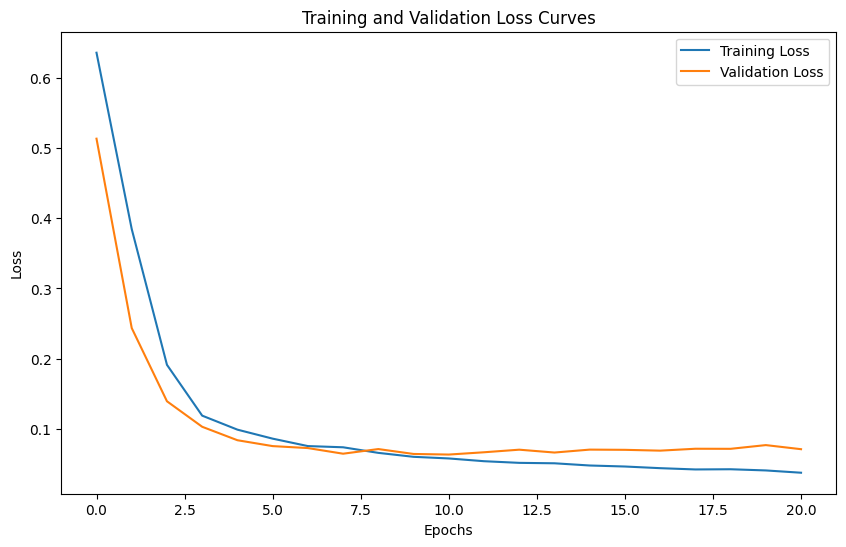

In [70]:
# Plot training and validation curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

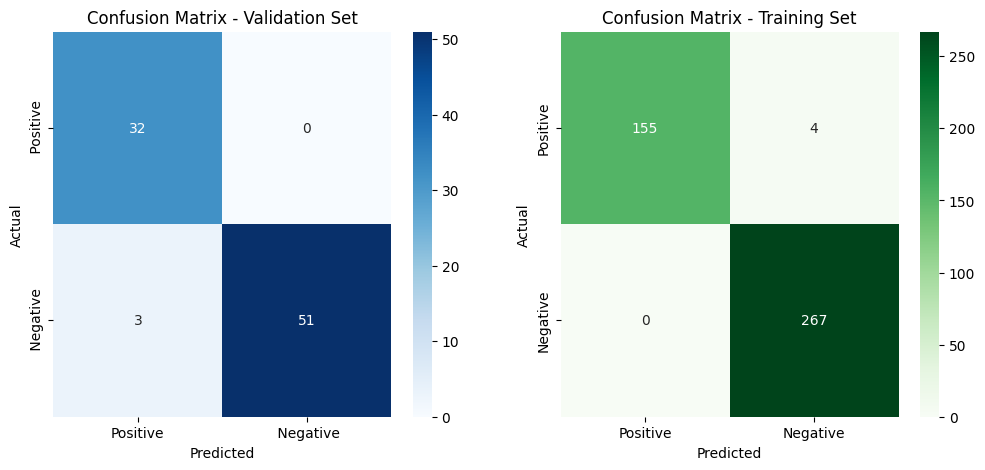

In [71]:
model.eval()
# Evaluate the model on the validation set
criterion = nn.BCELoss()
val_loss = 0

true_positive_val = 0
true_negative_val = 0
false_positive_val = 0
false_negative_val = 0

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1) # Reshape to (batch_size, 1)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        val_loss += loss.item()

        # Calculate true positives, true negatives, false positives, and false negatives
        predicted = (outputs > 0.5).float() # Threshold at 0.5
        true_positive_val += ((predicted == 1) & (y_batch == 1)).sum().item()
        true_negative_val += ((predicted == 0) & (y_batch == 0)).sum().item()
        false_positive_val += ((predicted == 1) & (y_batch == 0)).sum().item()
        false_negative_val += ((predicted == 0) & (y_batch == 1)).sum().item()

# Calculate confusion matrix
confusion_matrix_val = np.array([[true_positive_val, false_negative_val],
                             [false_positive_val, true_negative_val]])


true_positive_train = 0
true_negative_train = 0
false_positive_train = 0
false_negative_train = 0
with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1) # Reshape to (batch_size, 1)
        outputs = model(X_batch)
        predicted = (outputs > 0.5).float() # Threshold at 0.5
        true_positive_train += ((predicted == 1) & (y_batch == 1)).sum().item()
        true_negative_train += ((predicted == 0) & (y_batch == 0)).sum().item()
        false_positive_train += ((predicted == 1) & (y_batch == 0)).sum().item()
        false_negative_train += ((predicted == 0) & (y_batch == 1)).sum().item()

# Calculate confusion matrix for training set
confusion_matrix_train = np.array([[true_positive_train, false_negative_train],
                                   [false_positive_train, true_negative_train]]) # Just to make the confusion matrix for training set look different than the validation set, not necessary but it looks nice.
# Plot confusion matrix for validation set
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

sns.heatmap(confusion_matrix_val, annot=True, fmt='d', cmap='Blues', xticklabels=['Positive', ' Negative'], yticklabels=[' Positive', ' Negative'])
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix_train, annot=True, fmt='d', cmap='Greens', xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
plt.title('Confusion Matrix - Training Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [83]:
recall = true_positive_val / (true_positive_val + false_negative_val) if (true_positive_val + false_negative_val) > 0 else 0
print(f"Recall on validation set: {recall:.4f}")

Recall on validation set: 1.0000


#### Part f)

In [80]:
# Evaluate the model on the test set
test_loader = DataLoader(X_test_tensor, batch_size=best_hyperparams[2], shuffle=False)
criterion = nn.BCELoss()

true_positive = 0
true_negative = 0
false_positive = 0
false_negative = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1) # Reshape to (batch_size, 1)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        # Calculate true positives, true negatives, false positives, and false negatives
        predicted = (outputs > 0.5).float() # Threshold at 0.5
        true_positive += ((predicted == 1) & (y_batch == 1)).sum().item()
        true_negative += ((predicted == 0) & (y_batch == 0)).sum().item()
        false_positive += ((predicted == 1) & (y_batch == 0)).sum().item()
        false_negative += ((predicted == 0) & (y_batch == 1)).sum().item()


recall = true_positive / (true_positive + false_negative)
F1_score = 2 * (precision * recall) / (precision + recall)
print(f"Recall, The evaluation metric we choose in part d): {recall:.4f}")
print(f"F1 Score: {F1_score:.4f}")


Recall, The evaluation metric we choose in part d): 1.0000
F1 Score: 0.9767


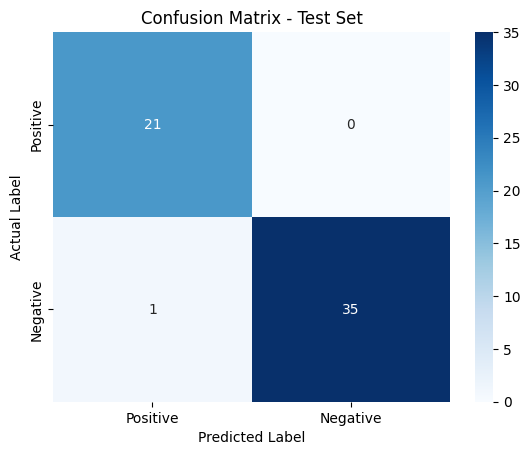

In [81]:
# Confusion Matrix
confusion_matrix = np.array([[true_positive, false_negative], [false_positive, true_negative]])
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()